In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
# Define the ODE
def f(t, y):
    return y**2 - 10

# Derivative of f with respect to y
def fprime(y):
    return 2 * y

In [30]:
# Newton-Raphson for single step with Backward Euler
def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y  # Initial guess
    
    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)
        
        if abs(g_prime_val) < tol:  # Avoid division by zero
            break
        
        y_new = y_next - g_val / g_prime_val
        
        if abs(y_new - y_next) < tol:
            return y_new  # Converged
        
        y_next = y_new
        
    return y_next

In [31]:
# Adaptive Backward Euler
def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]
    h_values = []
    
    h = h_init
    t = t0
    y = y0
    
    while t < tf:
        if t + h > tf:  # Adjust step size to not overshoot
            h = tf - t
        
        h_used = h
        
        # Single step with h
        y_full = backward_euler_step(f, y, t, h_used, tol, max_iter)
        
        # Two half-steps with h/2
        h_half = h_used / 2
        y_half_1 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)
        
        # Error estimation
        error = abs(y_full - y_half_2)
        
        # Adjust step size
        if error > tol:
            h = h_used / 2  # Decrease step size
            continue  # Retry the step with smaller h
        
        # Accept the step
        t += h_used
        y = y_half_2
        
        t_values.append(t)
        y_values.append(y)
        h_values.append(h_used)
        
        if error < tol / 2:
            h = h_used * 2  # Increase step size for efficiency
        else:
            h = h_used
    
    return np.array(t_values), np.array(y_values), np.array(h_values)

In [24]:
# Parameters
y0 = 0.5
t0 = 0
tf = 2
h_init = 0.1
tol = 1e-6

# Solve using adaptive Backward Euler
t_values, y_values, h_values = backward_euler_adaptive(f, y0, t0, tf, h_init, tol)

In [26]:
# Print results
print("t values:")
print(t_values)

print("\ny values:")
print(y_values)

print("\nh values used:")
print(h_values)

t values:
[0.0000000e+00 3.9062500e-04 7.8125000e-04 ... 1.9390625e+00 1.9890625e+00
 2.0000000e+00]

y values:
[ 0.5         0.49619029  0.49237911 ... -3.16223132 -3.16224311
 -3.16224538]

h values used:
[0.00039063 0.00039063 0.00039063 ... 0.05       0.05       0.0109375 ]


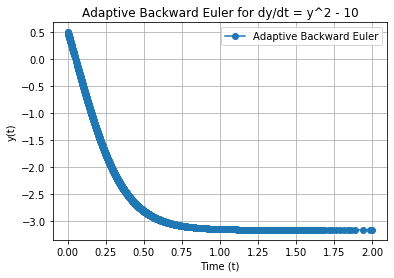

In [18]:
# Plot the solution
plt.plot(t_values, y_values, 'o-', label='Adaptive Backward Euler')
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.title('Adaptive Backward Euler for dy/dt = y^2 - 10')
plt.legend()
plt.grid(True)
plt.show()

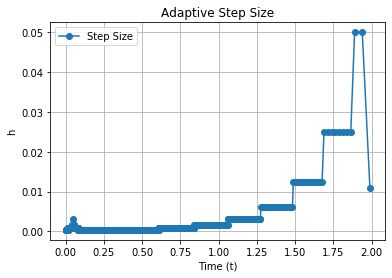

In [28]:
# Plot step sizes
plt.plot(t_values[:-1], h_values, 'o-', label='Step Size')
plt.xlabel('Time (t)')
plt.ylabel('h')
plt.title('Adaptive Step Size')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
print("Number of accepted steps:", len(h_values))
print("Smallest step size:", min(h_values))
print("Largest step size:", max(h_values))

Number of accepted steps: 2029
Smallest step size: 0.000390625
Largest step size: 0.05


In [21]:
print("The adaptive method decreases h when the estimated error is too large.")
print("It increases h when the error is small enough.")
print("The solution stays stable because Backward Euler is an implicit method.")

### AI used to refine code for conciseness, nicer plotting, and making sure all summaries and code is accurate

The adaptive method decreases h when the estimated error is too large.
It increases h when the error is small enough.
The solution stays stable because Backward Euler is an implicit method.
